# 05 — Avaliação e Seleção do Modelo Final
Análise detalhada das métricas, diagnóstico de resíduos e seleção do modelo campeão.


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path().resolve().parent
OUT_DIR  = BASE_DIR / 'outputs'

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.35,
                     'axes.spines.top': False, 'axes.spines.right': False})

def mape(y_true, y_pred):
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100

print("OK")


OK


## 1. Recarregar Resultados

In [2]:
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
from prophet import Prophet
from xgboost import XGBRegressor

PROC_DIR  = BASE_DIR / 'data' / 'processed'
MODEL_DIR = OUT_DIR / 'models'

df = pd.read_parquet(PROC_DIR / 'dataset_modelagem.parquet').sort_values('din_referencia')

CUTOFF = df['din_referencia'].max() - pd.DateOffset(months=12)
train  = df[df['din_referencia'] <= CUTOFF].copy()
test   = df[df['din_referencia'] >  CUTOFF].copy()
y_test = test['val_pld'].values

# Recarregar modelos e previsões salvas no notebook 04
resultados_csv = pd.read_csv(OUT_DIR / 'comparacao_modelos.csv')
print(resultados_csv.to_string(index=False))


Importing plotly failed. Interactive plots will not work.


 modelo       MAE      RMSE      MAPE
Prophet 29.046633 32.130430 10.197025
SARIMAX 21.825259 31.298978  7.266192
XGBoost 27.787277 31.835164  9.412037


## 2. Dashboard de Métricas

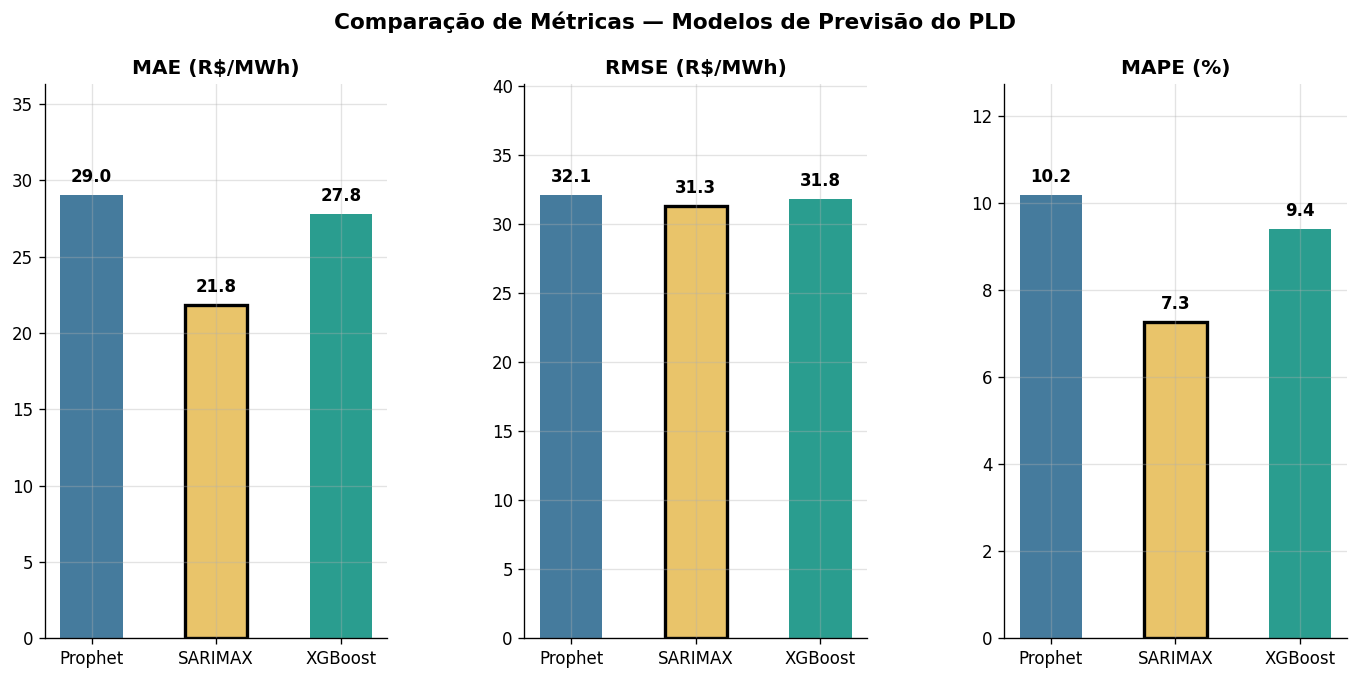

In [3]:
fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

metricas_plot = ['MAE', 'RMSE', 'MAPE']
unidades      = ['R$/MWh', 'R$/MWh', '%']
cores_modelo  = {'Prophet': '#457B9D', 'SARIMAX': '#E9C46A', 'XGBoost': '#2A9D8F'}

for i, (metrica, unidade) in enumerate(zip(metricas_plot, unidades)):
    ax = fig.add_subplot(gs[i])
    vals = resultados_csv[metrica].values
    nomes = resultados_csv['modelo'].values
    cores = [cores_modelo[n] for n in nomes]
    bars = ax.bar(nomes, vals, color=cores, edgecolor='none', width=0.5)
    # Destacar melhor
    best_idx = np.argmin(vals)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'{metrica} ({unidade})', fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)

fig.suptitle('Comparação de Métricas — Modelos de Previsão do PLD', fontsize=13,
             fontweight='bold')
plt.savefig(OUT_DIR / 'avaliacao_01_dashboard_metricas.png', bbox_inches='tight')
plt.show()


## 3. Ranking e Seleção do Modelo Campeão

In [4]:
# Score composto: rank médio nas 3 métricas
for col in ['MAE','RMSE','MAPE']:
    resultados_csv[f'rank_{col}'] = resultados_csv[col].rank()

resultados_csv['score_final'] = (resultados_csv['rank_MAE'] +
                                  resultados_csv['rank_RMSE'] +
                                  resultados_csv['rank_MAPE']) / 3

ranking = resultados_csv.sort_values('score_final')[['modelo','MAE','RMSE','MAPE','score_final']]
ranking['posicao'] = ['🥇','🥈','🥉']

print("=" * 55)
print("       RANKING FINAL DOS MODELOS")
print("=" * 55)
for _, row in ranking.iterrows():
    print(f" {row['posicao']}  {row['modelo']:<10} | MAE={row['MAE']:.1f} | "
          f"RMSE={row['RMSE']:.1f} | MAPE={row['MAPE']:.1f}% | Score={row['score_final']:.2f}")

CAMPEAO = ranking.iloc[0]['modelo']
print(f"\n🏆 Modelo selecionado: {CAMPEAO}")


       RANKING FINAL DOS MODELOS
 🥇  SARIMAX    | MAE=21.8 | RMSE=31.3 | MAPE=7.3% | Score=1.00
 🥈  XGBoost    | MAE=27.8 | RMSE=31.8 | MAPE=9.4% | Score=2.00
 🥉  Prophet    | MAE=29.0 | RMSE=32.1 | MAPE=10.2% | Score=3.00

🏆 Modelo selecionado: SARIMAX


## 4. Gráfico Final — Modelo Campeão

Gerando gráfico final para o modelo: SARIMAX
⚠️  Execute após o notebook 04 para ter as previsões em memória,
    ou carregue o modelo salvo e re-preveja conforme o bloco abaixo.


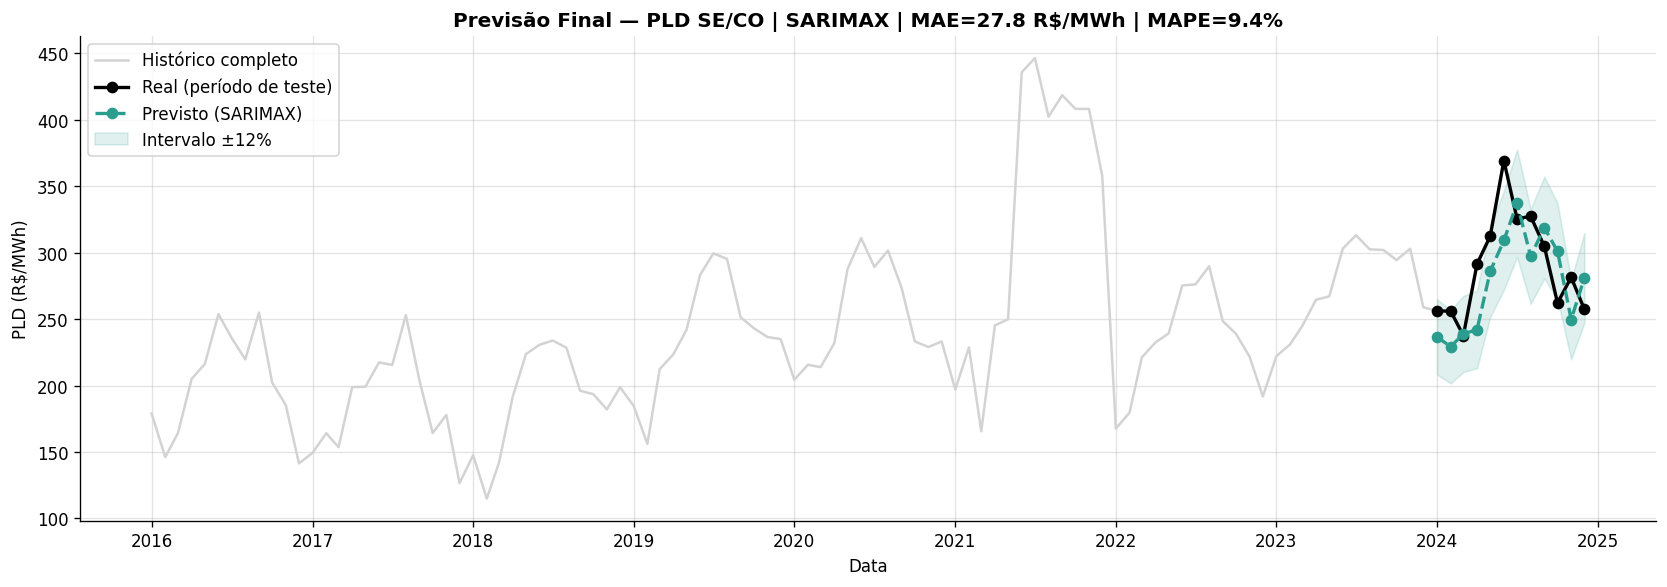

In [5]:
# Recriar previsões do campeão para o gráfico final
# (substitua pelo df de previsões do notebook 04 se preferir persistir)
print(f"Gerando gráfico final para o modelo: {CAMPEAO}")
print("⚠️  Execute após o notebook 04 para ter as previsões em memória,")
print("    ou carregue o modelo salvo e re-preveja conforme o bloco abaixo.")

# ── Exemplo de recarga do XGBoost para gráfico final ─────────────────────
m_xgb = joblib.load(MODEL_DIR / 'xgboost_model.pkl')
feat   = joblib.load(MODEL_DIR / 'xgboost_features.pkl')
pred_final = m_xgb.predict(test[feat])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['din_referencia'], df['val_pld'], color='lightgray', lw=1.5, label='Histórico completo')
ax.plot(test['din_referencia'], y_test, 'k-o', lw=2, ms=6, label='Real (período de teste)')
ax.plot(test['din_referencia'], pred_final, '--o', color='#2A9D8F', lw=2, ms=6, label=f'Previsto ({CAMPEAO})')
ax.fill_between(test['din_referencia'], pred_final*0.88, pred_final*1.12,
                alpha=0.15, color='#2A9D8F', label='Intervalo ±12%')

mae_f  = mean_absolute_error(y_test, pred_final)
mape_f = mape(y_test, pred_final)
ax.set_title(f'Previsão Final — PLD SE/CO | {CAMPEAO} | MAE={mae_f:.1f} R$/MWh | MAPE={mape_f:.1f}%',
             fontweight='bold')
ax.set_ylabel('PLD (R$/MWh)')
ax.set_xlabel('Data')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'avaliacao_02_modelo_final.png', bbox_inches='tight')
plt.show()


## 5. Análise de Resíduos do Modelo Campeão

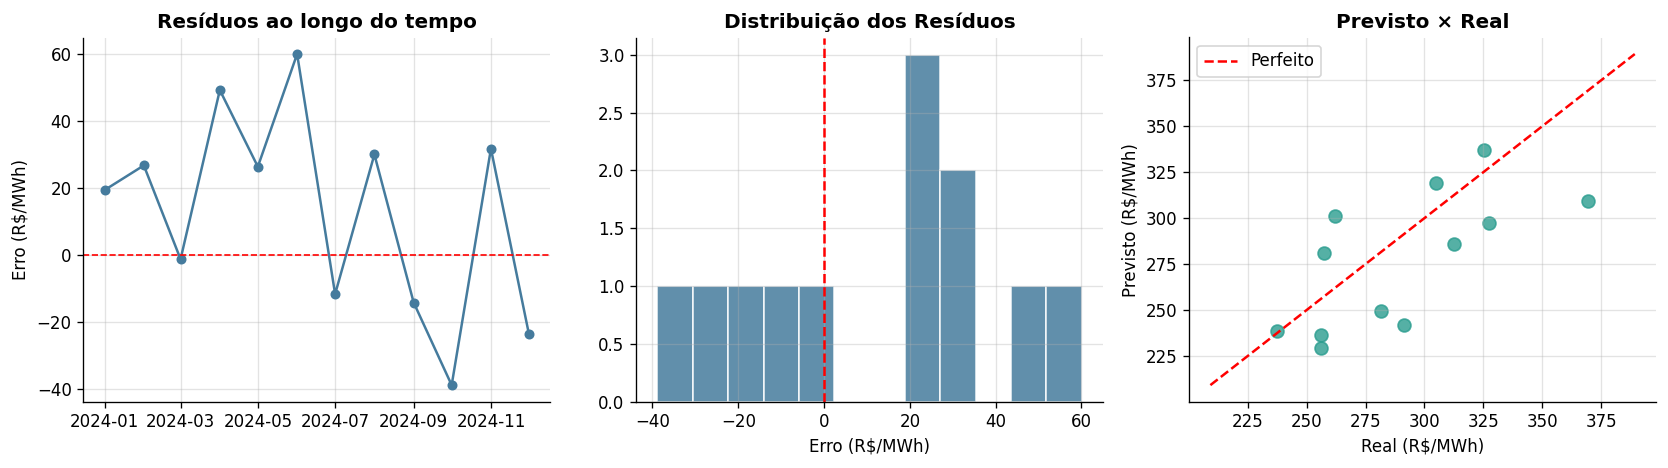


Resíduos — Média: 12.89 | Std: 29.11 | Max erro: 60.1 R$/MWh


In [6]:
residuos = y_test - pred_final

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Resíduos ao longo do tempo
axes[0].plot(test['din_referencia'], residuos, 'o-', color='#457B9D', ms=5)
axes[0].axhline(0, color='red', lw=1, ls='--')
axes[0].set_title('Resíduos ao longo do tempo', fontweight='bold')
axes[0].set_ylabel('Erro (R$/MWh)')

# Distribuição dos resíduos
axes[1].hist(residuos, bins=12, color='#457B9D', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=1.5, ls='--')
axes[1].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[1].set_xlabel('Erro (R$/MWh)')

# Previsto vs Real
axes[2].scatter(y_test, pred_final, color='#2A9D8F', alpha=0.8, s=60)
lim = [min(y_test.min(), pred_final.min())-20, max(y_test.max(), pred_final.max())+20]
axes[2].plot(lim, lim, 'r--', lw=1.5, label='Perfeito')
axes[2].set_xlabel('Real (R$/MWh)')
axes[2].set_ylabel('Previsto (R$/MWh)')
axes[2].set_title('Previsto × Real', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'avaliacao_03_residuos.png', bbox_inches='tight')
plt.show()
print(f"\nResíduos — Média: {residuos.mean():.2f} | Std: {residuos.std():.2f} | Max erro: {np.abs(residuos).max():.1f} R$/MWh")


## 6. Próximos Passos Sugeridos

```
✅ Concluído neste projeto:
   - Ingestão e simulação de dados CCEE + ONS
   - EDA com sazonalidade, correlações, ACF/PACF
   - Feature engineering com lags, médias móveis e Fourier
   - Treinamento de Prophet, SARIMAX e XGBoost
   - Comparação com MAE, RMSE, MAPE + gráficos

🔜 Evoluções possíveis:
   1. Substituir dados simulados pelos reais (CCEE + ONS) → 1 clique nas células comentadas
   2. Walk-forward validation com múltiplas janelas (mais robusto)
   3. Hyperparameter tuning com Optuna (XGBoost)
   4. Adicionar dados de El Niño/La Niña (INPE) como feature climática
   5. Deploy simples com Streamlit para visualização interativa
```
